In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import dataframe_image as dfi

plt.style.use('seaborn-v0_8-pastel')

In [2]:
caminho_base = rf'C:\Users\Projeto 7\OneDrive - SANOVA\13. Consultoria - PNA_SANETER_SC\03. EXE\06. Parque de hidrômetros\Análise dos dados'

df = pd.read_excel(fr'{caminho_base}\1.2. Dados tratados.xlsx')
df_analise = df

In [3]:
df_analise.columns
df_analise['Número do HD'].isna().sum()

767

In [4]:
def analise_idade(idade):
    if idade < 5:
        return "menor que 5"
    if idade>=5 and idade <8:
        return "de 5 a 8"
    if idade>=8 and idade<10:
        return "de 8 a 10"
    if idade>=10 and idade<15:
        return "de 10 a 15"
    if idade>=15 and idade<20:
        return "de 15 a 20"
    if idade>=20:
        return "maior que 20"

In [5]:
ganho_financeiro_count = (df_analise['Ganho financeiro com ajustes (R$/ano)'] > 0).sum()
no_ganho_financeiro_count = (df_analise['Ganho financeiro com ajustes (R$/ano)'] == 0).sum()

print(f'Existem {ganho_financeiro_count} casos onde, ao trocar o hidrômetro por causa da idade, haverá um ganho financeiro, e {no_ganho_financeiro_count} casos onde, mesmo que o hidrômetro esteja velho, não haverá ganho financeiro.')

ganho_financeiro_anual = df_analise['Ganho financeiro com ajustes (R$/ano)'].sum()
formatted_ganho_financeiro = f"R${ganho_financeiro_anual:,.2f}"

print(f'O ganho financeiro potencial é de {formatted_ganho_financeiro} em 1 ano de consumo')

menos_1_ano = (df_analise['Tempo para retorno financeiro (meses)'] < 12).sum()
total_hidrometros = (df_analise['Ganho financeiro com ajustes (R$/ano)'] > 0).sum()

print(f'Dos {total_hidrometros} hidrômetros que terão retorno financeiro, {menos_1_ano} têm seu retorno em menos de 1 ano.')


Existem 19563 casos onde, ao trocar o hidrômetro por causa da idade, haverá um ganho financeiro, e 19459 casos onde, mesmo que o hidrômetro esteja velho, não haverá ganho financeiro.
O ganho financeiro potencial é de R$6,655,643.04 em 1 ano de consumo
Dos 19563 hidrômetros que terão retorno financeiro, 8967 têm seu retorno em menos de 1 ano.


# Critério 1

Total de matrículass: 58174
Total de matrículas sem informação de idade: 767
Total de matrículas com informações de idade: 57407
57407


C:\Users\Projeto 7\AppData\Local\Temp\ipykernel_4408\3710599160.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_idade['Idade'] = df_analise['Idade do HD (anos)'].apply(analise_idade)


,Idade,Contagem
0,de 5 a 8,19003
1,menor que 5,17908
2,de 10 a 15,10747
3,de 8 a 10,5039
4,de 15 a 20,4710


(array([], dtype=float64), [])

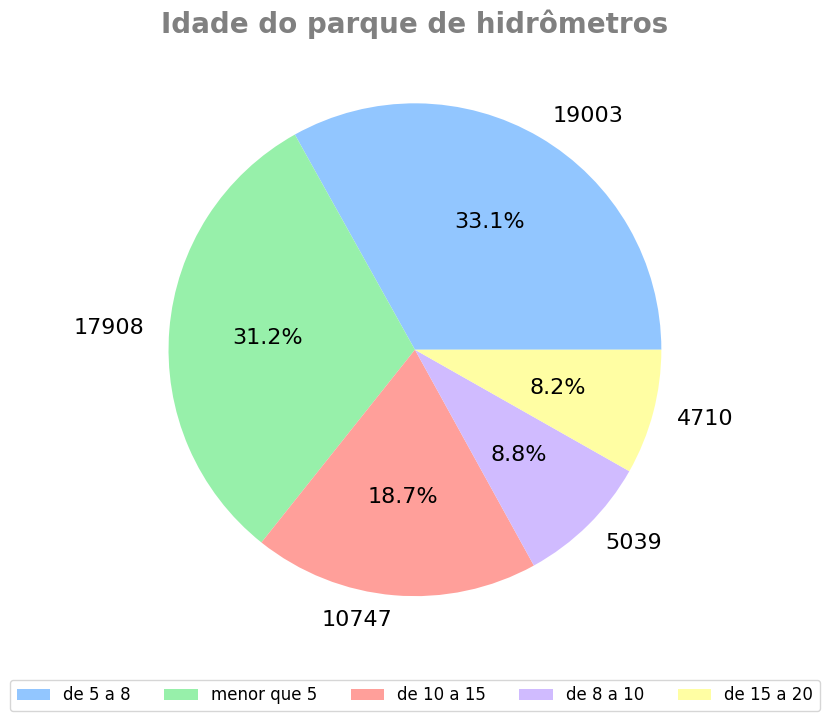

In [6]:
df_idade = df_analise[['Idade do HD (anos)']]
nan_count = df_analise['Idade do HD (anos)'].isna().sum()
print(f'Total de matrículass: {len(df_analise)}')
print(f'Total de matrículas sem informação de idade: {nan_count}')
print(f'Total de matrículas com informações de idade: {df_idade["Idade do HD (anos)"].value_counts().sum()}')

df_idade['Idade'] = df_analise['Idade do HD (anos)'].apply(analise_idade)

# Transformar a série em um novo DataFrame
df_idade_counts = df_idade['Idade'].value_counts().reset_index()

# Renomear as colunas
df_idade_counts.columns = ['Idade', 'Contagem']
print(df_idade['Idade'].value_counts().sum())
# Exibir o DataFrame personalizado
display(df_idade_counts)

# Plotar um gráfico de barras

plt.figure(figsize=(15,8))
label_props = {'fontsize': 16}
plt.pie(df_idade_counts['Contagem'],labels=df_idade_counts['Contagem'], autopct='%1.1f%%', textprops=label_props)
plt.title('Idade do parque de hidrômetros',fontsize=20, fontweight='bold',color = "grey")
plt.legend(df_idade_counts['Idade'], loc='lower center', fontsize=12,ncol=5, bbox_to_anchor=(0.5, -0.1))
plt.xticks(rotation=45)  # Rotaciona os rótulos do eixo x para facilitar a leitura

#df_idade_counts.to_excel(fr'{caminho_base}\Gráficos e tabelas\Critério 1 - Idade\Análise 1 (Excel) - C1 - Idade dos hidrômetros.xlsx')
#plt.savefig(fr'{caminho_base}\Gráficos e tabelas\Critério 1 - Idade\Análise 1 (Gráfico) - C1 - Idade dos hidrômetros.png', dpi=300, bbox_inches='tight')

,Idade do HD (anos),Quantidade
13,0.0,1170
6,1.0,3531
9,2.0,2995
1,3.0,5202
12,4.0,1549
0,5.0,11661
2,6.0,4312
3,7.0,4223
5,8.0,3785
10,9.0,2736


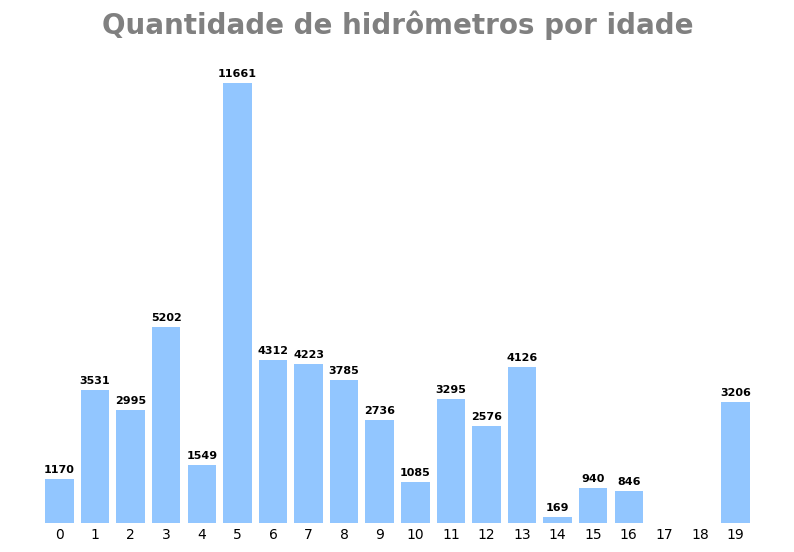

In [7]:
# Seu código para contar e plotar as idades e quantidades
df_idade_contagem = round(df_analise[['Idade do HD (anos)']],0).value_counts().reset_index(name='Quantidade').sort_values(by='Idade do HD (anos)')
display(df_idade_contagem)


plt.figure(figsize=(10, 6))
barra = plt.bar(df_idade_contagem['Idade do HD (anos)'], df_idade_contagem['Quantidade'])

# Adicionar o valor da quantidade em cima de cada barra

plt.bar_label(barra, labels=df_idade_contagem['Quantidade'], padding=3, fontsize=8, fontweight='bold')

# Remover o box
plt.box(False)

# Definir os rótulos de idade de 1 em 1
plt.xticks(range(int(min(df_idade_contagem['Idade do HD (anos)'])), int(max(df_idade_contagem['Idade do HD (anos)'])) + 1, 1))

# Remover os ticks
plt.tick_params(axis='both', which='both', length=0)

plt.ylabel('')
plt.yticks([])

plt.title('Quantidade de hidrômetros por idade',pad=20,fontsize=20, fontweight='bold',color = "grey")


#plt.savefig(fr'{caminho_base}\Gráficos e tabelas\Critério 1 - Idade\Análise 2 (Gráfico) - C1 - Distribuição das idades.png', dpi=300, bbox_inches='tight')
#df_idade_counts.to_excel(fr'{caminho_base}\Gráficos e tabelas\Critério 1 - Idade\Análise 2 (Excel) - C1 - Distribuição das idades.xlsx')
plt.show()

# Critério 2

In [8]:
# Pegar apenas os classificados para troca
df_vmax = df_analise[df_analise['Classificação 2: Limite de registro'] == 'Classificado para troca']

# Contar quantos classificados para troca para cada registro máximo
contagem = df_vmax.groupby('Registro máximo (m³)')['Classificação 2: Limite de registro'].count()

# Se você quiser incluir os valores '0' para aqueles que não são classificados para troca, pode usar reindex
contagem = contagem.reindex(df_analise['Registro máximo (m³)'].unique(), fill_value=0)

# Definir o nome da série
contagem.name = 'Quantidade de hidrômetros que excederam o limite'
contagem = contagem.reset_index()

contagem_dois = df_vmax.groupby('Registro máximo (m³)')['Registro estimado (m³)'].max()
contagem_dois = contagem_dois
contagem_dois.name = 'Maior volume acumulado (m³)'

# Transformar as séries em DataFrames
contagem_dois = contagem_dois.reset_index()

# Juntar os DataFrames
contagem = contagem.merge(contagem_dois, on='Registro máximo (m³)', how='outer').sort_values(by='Registro máximo (m³)').dropna()
#contagem.to_excel(fr'{caminho_base}\Gráficos e tabelas\Critério 2 - Registro Máximo\Análise 1 (Excel) - Quantidade de hidrômetros que excederam os limites.xlsx')

display(contagem)




,Registro máximo (m³),Quantidade de hidrômetros que excederam o limite,Maior volume acumulado (m³)
0,2900.0,2825,134373.36
1,10000.0,48,144700.92
3,45000.0,7,86433.19
5,65000.0,4,306336.42
4,100000.0,6,441885.45


# Critério 3

In [9]:
# Filtrar as linhas onde 'CLASSIFICACAO_DIMENSIONAMENTO' é "Classificado para troca"
classificados_para_troca = df_analise[df_analise['Classificação 3: Dimensionamento'] == "Classificado para troca"]
classificados_para_troca['Irregularidade no dimensionamento'] = np.where(classificados_para_troca['Capacidade do HD (Qmáx em m³/h)'] < classificados_para_troca['Capacidade ideal (m³/h)'],'Subdimencionamento','Superdimencionamento')

# Agora você tem as linhas de subdimensionamento e superdimensionamento em 'subdimensionamento' e 'superdimensionamento', respectivamente
classificados_para_troca = pd.DataFrame(classificados_para_troca['Irregularidade no dimensionamento'].value_counts()).reset_index()
classificados_para_troca.columns = ['Irregularidade no dimensionamento', 'Quantidade']
display(classificados_para_troca)
#classificados_para_troca.to_excel(fr'{caminho_base}\Gráficos e tabelas\Critério 3 - Dimensionamento\Análise 1 (Excel) - Quantidade de hidrômetros mal dimensionados.xlsx')

C:\Users\Projeto 7\AppData\Local\Temp\ipykernel_4408\3088823288.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  classificados_para_troca['Irregularidade no dimensionamento'] = np.where(classificados_para_troca['Capacidade do HD (Qmáx em m³/h)'] < classificados_para_troca['Capacidade ideal (m³/h)'],'Subdimencionamento','Superdimencionamento')


,Irregularidade no dimensionamento,Quantidade
0,Superdimencionamento,6349
1,Subdimencionamento,178


# Resumo

Matrículas ativas cadastradas: 58174
Com dados de HD: 57407
Sem dados de HD: 0
Não classificado para troca: 16308


,Critério de troca,Contagem
1,Sem troca - UCs não classificadas para troca,16308
0,"C1 - UCs classificadas para troca por idade, s...",31648
6,C2 - UCs classificadas para troca por extrapol...,215
5,C3 - UCs classificadas para troca por dimensio...,1185
3,C1 e C2 - UCs classificadas para troca por ida...,2464
2,C1 e C3 - UCs classificadas para troca por ida...,4591
8,C2 e C3 - UCs classificadas para troca por lim...,99
7,Todos os critérios - UCs classificadas pelos t...,112
4,Desconhecido,1552


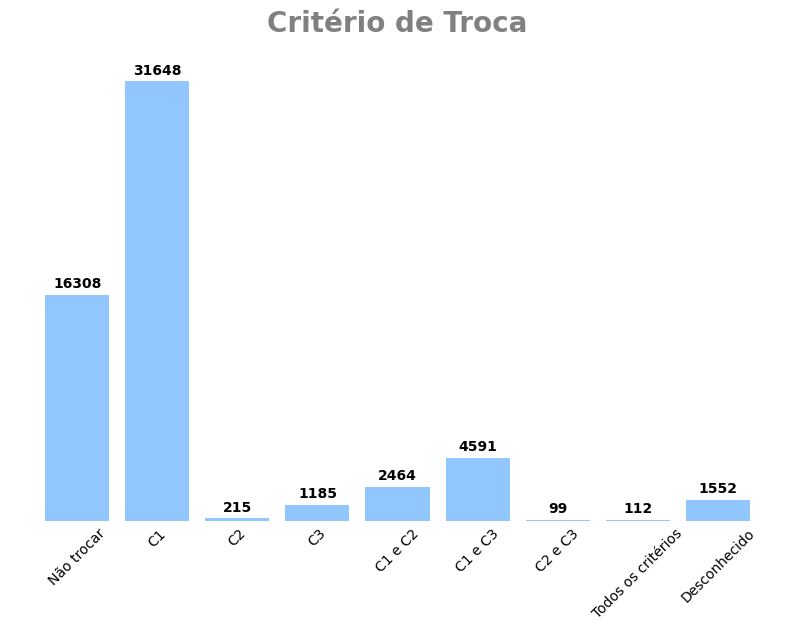

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import dataframe_image as dfi

# Matrículas ativas
ativas = df_analise['Matrícula'].count()
print(f'Matrículas ativas cadastradas: {ativas}')

# Matrículas com dados
comdados = df_analise[df_analise["Número do HD"].notna()]
comdados_count = comdados["Número do HD"].count()
print(f'Com dados de HD: {comdados_count}')

# Matrículas sem dados
semdados = df_analise[df_analise['Número do HD'].isna()]
semdados_count = semdados['Número do HD'].count()
print(f'Sem dados de HD: {semdados_count}')

# Matrículas não classificadas para troca
ntrocar = comdados[comdados['Critério de troca'].str.startswith('Sem troca') | comdados['Critério de troca'].isna()]
ntrocar_count = ntrocar["Critério de troca"].count()
print(f'Não classificado para troca: {ntrocar_count}')
df_analise['Critério de troca'] = df_analise['Critério de troca'].fillna('Desconhecido').astype(str)

# Matrículas classificadas para troca
df_resumo = df_analise['Critério de troca'].value_counts().reset_index()
df_resumo.columns = ['Critério de troca', 'Contagem']
nova_ordem = [1, 0, 6, 5, 3, 2, 8, 7, 4]
df_resumo = df_resumo.iloc[nova_ordem]

# Display the DataFrame
display(df_resumo)

# Plotar um gráfico de barras
plt.figure(figsize=(10, 6))
grafico4 = plt.bar(['Não trocar', 'C1', 'C2', 'C3', 'C1 e C2', 'C1 e C3', 'C2 e C3', 'Todos os critérios', 'Desconhecido'], df_resumo['Contagem'])
plt.xlabel('Critério de troca')
plt.ylabel('Contagem')
plt.xticks(rotation=45)  # Rotaciona os rótulos do eixo x para facilitar a leitura
plt.savefig('Análise 4 (gráfico) - Resumo.png', dpi=300, bbox_inches='tight')
plt.bar_label(grafico4, labels=df_resumo['Contagem'], fontweight='bold', padding=3)

plt.tick_params(axis='both', which='both', length=0)

plt.ylabel('')
plt.xlabel('')
plt.yticks([])
plt.box(False)

plt.title('Critério de Troca',pad=20,fontsize=20, fontweight='bold',color = "grey")

plt.savefig(fr'{caminho_base}\Gráficos e tabelas\Resumo (Gráfico) - Distribuição dos critérios.png', dpi=300, bbox_inches='tight')
df_idade_counts.to_excel(fr'{caminho_base}\Gráficos e tabelas\Resumo (Excel) - Distribuição dos critérios.xlsx')
plt.show()

# Exportar tabela como imagem
